In [ ]:
import pandas as pd
df=pd.read_csv(r"E:\sar\csv\transposed_output2019all.csv", parse_dates=["coherence"], index_col=[30])
print(df.shape)
print(df.head())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

# 读取CSV文件
data = pd.read_csv(r'E:\sar\csv\transposed_output2019all.csv')

# 假设第一列为时间，第二列为形变量
time = pd.to_datetime(data.iloc[:, 0])  # 确保时间列是datetime格式
displacement = data.iloc[:, 18000]

# 计算Z-score
z_scores = zscore(displacement)

# 设置一个阈值，通常认为Z-score大于3或小于-3的点为异常值
threshold = 3
abnormal_points = data[abs(z_scores) > threshold]

# 打印异常值的时间点
print("异常值的时间点：")
print(abnormal_points.iloc[:, 0])  # 打印时间列中的异常值对应的时间

# 绘制折线图
plt.figure(figsize=(20, 6))  # 增加图表宽度，避免标签重叠
plt.plot(time, displacement)
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('Displacement vs Time')

# 显示所有时间点的横轴标签
plt.xticks(time, rotation=45)  # 显示所有时间点，横轴标签旋转45度以避免重叠
plt.grid(True)
plt.tight_layout()  # 自动调整布局以避免标签重叠
plt.show()


In [ ]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
 
np.random.seed(0)
 
 
def calculate_mae(y_true, y_pred):
    # 平均绝对误差
    mae = np.mean(np.abs(y_true - y_pred))
    return mae
 
 
true_data = pd.read_csv('transposed_result.csv') # 填你自己的数据地址
 
target = 'OT'
 
 
# 这里加一些数据的预处理, 最后需要的格式是pd.series
 
true_data = np.array(true_data['OT'])
 
# 定义窗口大小
test_data_size = 32
# 训练集和测试集的尺寸划分
test_size = 0.15
train_size = 0.85
# 标准化处理
scaler_train = MinMaxScaler(feature_range=(0, 1))
scaler_test = MinMaxScaler(feature_range=(0, 1))
train_data = true_data[:int(train_size * len(true_data))]
test_data = true_data[-int(test_size * len(true_data)):]
print("训练集尺寸:", len(train_data))
print("测试集尺寸:", len(test_data))

train_data =  true_data[:, 1:] # 删除时间列
test_data =  true_data[:, 1:]  # 删除时间列

train_data_normalized = scaler_train.fit_transform(train_data.reshape(-1, 1))
test_data_normalized = scaler_test.fit_transform(test_data.reshape(-1, 1))
# 转化为深度学习模型需要的类型Tensor
train_data_normalized = torch.FloatTensor(train_data_normalized).view(-1)
test_data_normalized = torch.FloatTensor(test_data_normalized).view(-1)
 
 
def create_inout_sequences(input_data, tw, pre_len):
    inout_seq = []
    L = len(input_data)
    for i in range(L - tw):
        train_seq = input_data[i:i + tw]
        if (i + tw + 4) > len(input_data):
            break
        train_label = input_data[i + tw:i + tw + pre_len]
        inout_seq.append((train_seq, train_label))
    return inout_seq
 
pre_len = 4
train_window = 16
# 定义训练器的的输入
train_inout_seq = create_inout_sequences(train_data_normalized, train_window, pre_len)
 
 
class LSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=350, output_dim=1):
        super(LSTM, self).__init__()
 
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
 
    def forward(self, x):
        x = x.unsqueeze(1)
 
        h0_lstm = torch.zeros(1, self.hidden_dim).to(x.device)
        c0_lstm = torch.zeros(1, self.hidden_dim).to(x.device)
 
        out, _ = self.lstm(x, (h0_lstm, c0_lstm))
        out = out[:, -1]
        out = self.fc(out)
 
        return out
 
 
lstm_model = LSTM(input_dim=1, output_dim=pre_len, hidden_dim=train_window)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
epochs = 10
Train = True  # 训练还是预测
 
if Train:
    losss = []
    lstm_model.train()  # 训练模式
    start_time = time.time()  # 计算起始时间
    for i in range(epochs):
        for seq, labels in train_inout_seq:
            lstm_model.train()
            optimizer.zero_grad()
 
            y_pred = lstm_model(seq)
 
            single_loss = loss_function(y_pred, labels)
 
            single_loss.backward()
            optimizer.step()
            print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')
            losss.append(single_loss.detach().numpy())
    torch.save(lstm_model.state_dict(), 'save_model.pth')
    print(f"模型已保存,用时:{(time.time() - start_time) / 60:.4f} min")
    plt.plot(losss)
    # 设置图表标题和坐标轴标签
    plt.title('Training Error')
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    # 保存图表到本地
    plt.savefig('training_error.png')
else:
    # 加载模型进行预测
    lstm_model.load_state_dict(torch.load('save_model.pth'))
    lstm_model.eval()  # 评估模式
    results = []
    reals = []
    losss = []
    test_inout_seq = create_inout_sequences(test_data_normalized, train_window, pre_len)
    for seq, labels in train_inout_seq:
        pred = lstm_model(seq)[0].item()
        results.append(pred)
        mae = calculate_mae(pred, labels.detach().numpy())  # MAE误差计算绝对值(预测值  - 真实值)
        reals.append(labels.detach().numpy())
        losss.append(mae)
 
    print("模型预测结果：", results)
    print("预测误差MAE:", losss)
 
    plt.style.use('ggplot')
 
    # 创建折线图
    plt.plot(results, label='real', color='blue')  # 实际值
    plt.plot(reals, label='forecast', color='red', linestyle='--')  # 预测值
 
    # 增强视觉效果
    plt.grid(True)
    plt.title('real vs forecast')
    plt.xlabel('time')
    plt.ylabel('value')
    plt.legend()
    plt.savefig('test——results.png')

In [ ]:
# import pandas as pd

# # 指定文件路径和列名
# filename = r'E:\sar\csv\transposed_output2019all.csv'
# names = [str(i) for i in range(5)] 

# # 读取数据集并指定列名
# dataset = pd.read_csv(filename, names=names, delim_whitespace=True)

# # 显示数据集
# print(dataset)

# # 转换为 DataFrame
# df = pd.DataFrame(dataset)
import pandas as pd
import matplotlib.pyplot as plt

# 指定文件路径和列名
filename = r'E:\sar\csv\transposed_output2019all.csv'
names = [str(i) for i in range(5)]  # 创建列名 ['0','1','2','3','4']

# 读取数据集（使用空格或制表符分隔）
dataset = pd.read_csv(filename, names=names, delim_whitespace=True)

# 转换为DataFrame（读取后已经是DataFrame，此步可选）
df = pd.DataFrame(dataset)

# 选择要绘制的列（例如列 '0'）
selected_column = '0'  # 可更改为 '1','2','3','4' 中的任意一个

# 创建图形
plt.figure(figsize=(12, 6))
plt.plot(df[selected_column], color='blue', linewidth=1)

# 添加标题和标签
plt.title(f'Time Series of Column {selected_column}', fontsize=14)
plt.xlabel('Index (Time Points)', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 优化布局
plt.tight_layout()

# 显示图形
plt.show()

原始数据的最小值: -15.5
原始数据的最大值: 11.300000190734863
数据集的结束时间: 2022-12-23 00:00:00


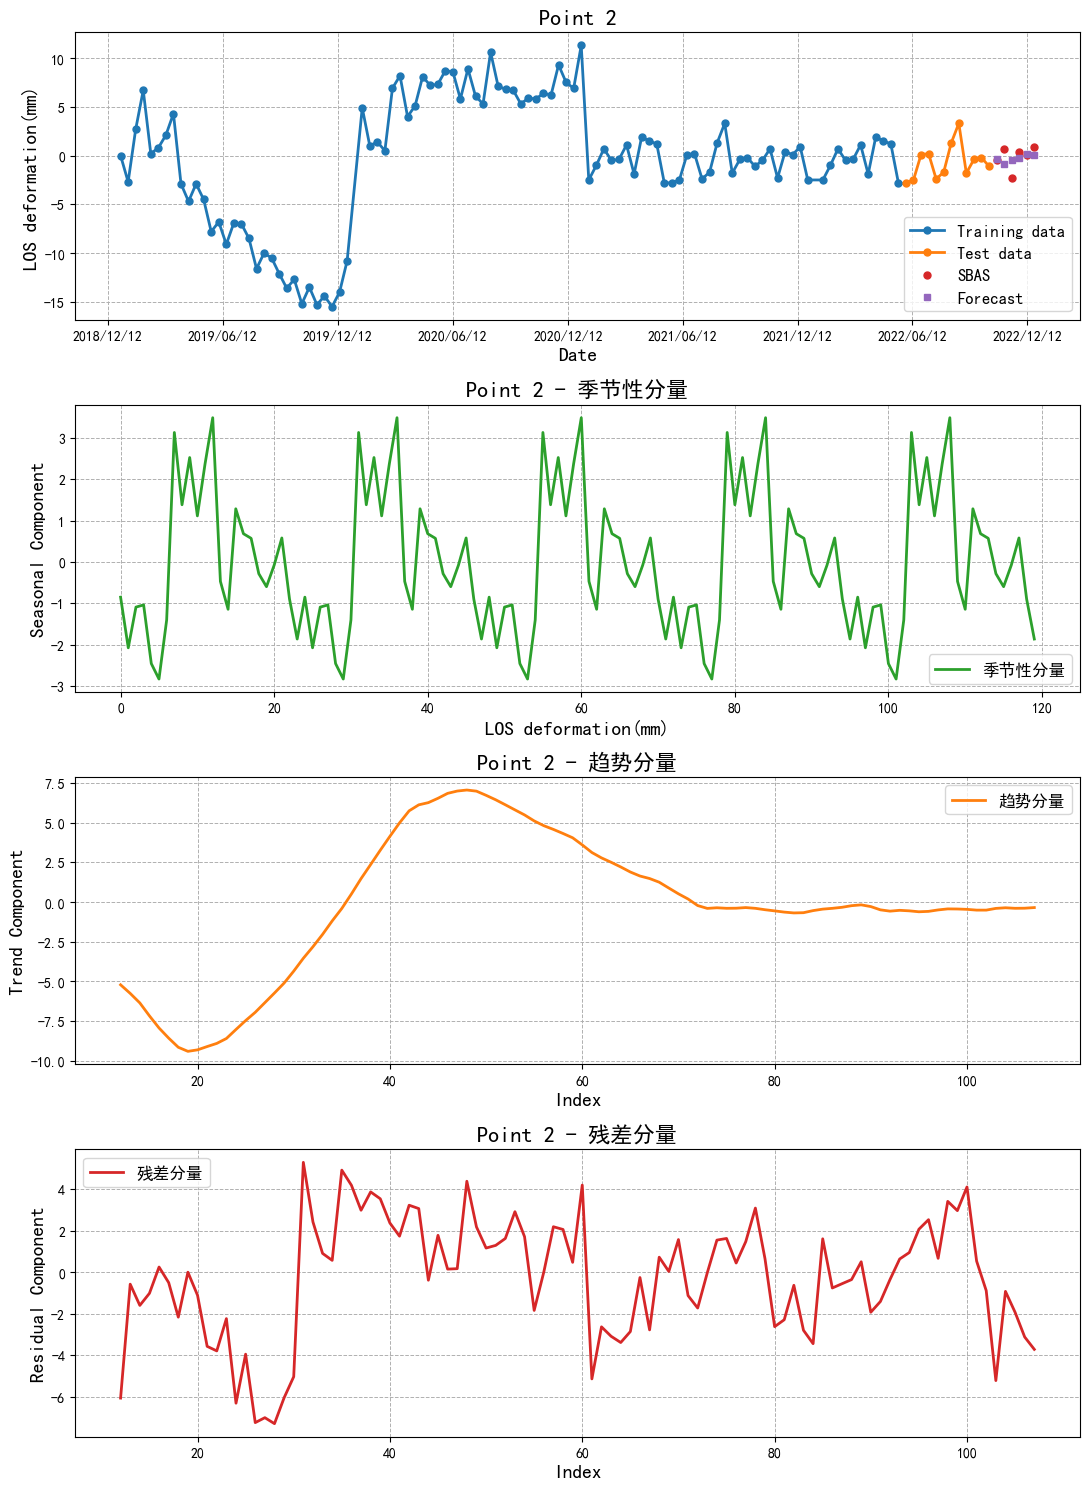

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.signal import savgol_filter
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates
rcParams['font.family'] = 'SimHei'  # 设置字体为系统中的SimHei
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 读取CSV文件
filename = r'E:\sar\csv\transposed_output2019_2022.csv'
data = pd.read_csv(filename)
filename1 = r'E:\repository\prediction_results.csv'
data1 = pd.read_csv(filename1)


# 假设你想绘制CSV文件中的某一列的折线图


column_name = '2'
column_date= 'Date'
# 获取原始数据
raw_data = data[column_name]
column_name2 = f'{column_name}_Pred'
column_name3 = f'{column_name}_Pred'
raw_data2= data1[column_name2]
raw_data3= data1[column_name3]
raw_data_part = raw_data.iloc[:102]
raw_data_part1 = raw_data.iloc[102:114]
raw_data_part2 = raw_data.iloc[-6:]
raw_data3_last6 = raw_data3.iloc[-6:]

# # 合并 raw_data_part 和 raw_data3_last6
# combined_data = pd.concat([raw_data_part, raw_data3_last6], ignore_index=True)
# # 拼接原数据和最后6个数据



# 使用Savitzky-Golay滤波器进行平滑，窗口大小为5，阶数为3（可以根据需要调整）
smoothed_data = savgol_filter(raw_data, window_length=5, polyorder=3)

# 对原始数据进行季节性分解
# 注意：分解时需要指定周期性（seasonal_periods）。例如，如果数据是日数据，季节周期可能是365（如果为年度数据）。
decomposition = seasonal_decompose(raw_data, model='additive', period=24)  # 请根据你的数据调整周期

# 获取季节性分量、趋势分量和残差分量
seasonal_component = decomposition.seasonal
trend_component = decomposition.trend
residual_component = decomposition.resid
min_value = raw_data.min() - 0.05  # 根据数据调整最小值
max_value = raw_data.max() + 0.05  # 根据数据调整最大值
print(f"原始数据的最小值: {raw_data.min()}")
print(f"原始数据的最大值: {raw_data.max()}")


data[column_date] = pd.to_datetime(data[column_date])

print(f"数据集的结束时间: {data[column_date].max()}")
plt.figure(figsize=(11, 15))

# 绘制原始数据的折线图
plt.subplot(4, 1, 1)


# plt.plot(raw_data_part, marker='o', color='tab:blue', linestyle='-', linewidth=2, markersize=5, label='Training data')
# plt.plot(raw_data_part1, marker='o', color='tab:orange', linestyle='-', linewidth=2, markersize=5, label='Test data')
# plt.plot(raw_data_part2, marker='o', color='tab:red', linestyle='none', linewidth=2, markersize=5, label='SBAS') 
# plt.plot(range(113, 119), raw_data3_last6, marker='s', color='tab:purple', linestyle='none', linewidth=2, markersize=5, label='Forecast Data')
plt.plot(data[column_date][:102], raw_data_part, marker='o', color='tab:blue', linestyle='-', linewidth=2, markersize=5, label='Training data')
plt.plot([data[column_date].iloc[101], data[column_date].iloc[102]], 
         [raw_data_part.iloc[-1], raw_data_part1.iloc[0]], 
         color='tab:blue', linestyle='-', linewidth=2)
plt.plot(data[column_date][102:114], raw_data_part1, marker='o', color='tab:orange', linestyle='-', linewidth=2, markersize=5, label='Test data')
plt.plot(data[column_date][-6:], raw_data_part2, marker='o', color='tab:red', linestyle='none', linewidth=2, markersize=5, label='SBAS') 
plt.plot(data[column_date].iloc[114:120], raw_data3_last6, marker='s', color='tab:purple', linestyle='none', linewidth=2, markersize=5, label='Forecast')

# plt.plot(raw_data3, marker='s', color='tab:purple', linestyle='--', linewidth=2, markersize=5, label='预测数据',alpha=0.5)
# plt.plot(raw_data2, marker='s', color='tab:red', linestyle='--', linewidth=2, markersize=5, label='真实数据')
# plt.plot(smoothed_data, marker='x', color='tab:orange', linestyle='-', linewidth=2, markersize=5, label='平滑数据')



plt.title(f'Point {column_name}', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('LOS deformation(mm)', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.7)
plt.legend(fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # 根据数据调整刻度
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=12, interval=6))

# 绘制季节性分量图
plt.subplot(4, 1, 2)
plt.plot(seasonal_component, color='tab:green', label='季节性分量', linewidth=2)
plt.title(f'Point {column_name} - 季节性分量', fontsize=16, fontweight='bold')
plt.xlabel('LOS deformation(mm)', fontsize=14)
plt.ylabel('Seasonal Component', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.7)
plt.legend(fontsize=12)

# 绘制趋势分量图
plt.subplot(4, 1, 3)
plt.plot(trend_component, color='tab:orange', label='趋势分量', linewidth=2)
plt.title(f'Point {column_name} - 趋势分量', fontsize=16, fontweight='bold')
plt.xlabel('Index', fontsize=14)
plt.ylabel('Trend Component', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.7)
plt.legend(fontsize=12)

# 绘制残差分量图
plt.subplot(4, 1, 4)
plt.plot(residual_component, color='tab:red', label='残差分量', linewidth=2)
plt.title(f'Point {column_name} - 残差分量', fontsize=16, fontweight='bold')
plt.xlabel('Index', fontsize=14)
plt.ylabel('Residual Component', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.7)
plt.legend(fontsize=12)

# 调整布局
plt.tight_layout()  # 自动调整子图参数，避免标签重叠
plt.show()




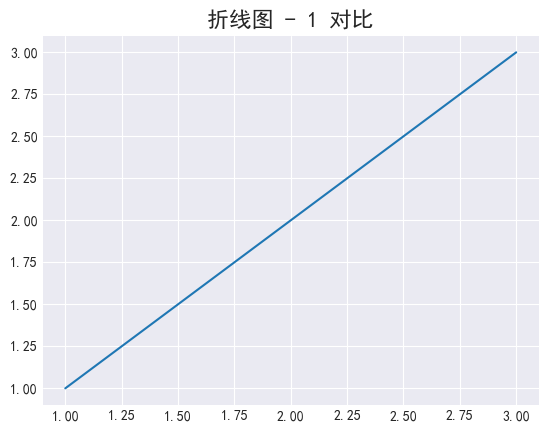

In [ ]:
# import matplotlib.pyplot as plt
# from matplotlib import rcParams

# # 设置字体为SimHei，解决中文显示问题
# rcParams['font.family'] = 'SimHei'  # 可以设置为你系统中可用的中文字体
# rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# # 测试
# plt.plot([1, 2, 3], [1, 2, 3])
# plt.title(f'折线图 - {column_name} 对比', fontsize=16, fontweight='bold')
# plt.show()


In [90]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os


# 读取数据
data_path = r'E:\sar\csv\transposed_output2019_2022.csv'  # 填你自己的数据地址
raw_data = pd.read_csv(data_path)

# 选择要训练的列（可以选择多个点）
# 方式1: 选择特定的列
target_columns = ['281']  # 可以根据需要修改选择的列

# 方式2: 选择所有数值列（除了可能的日期/索引列）
# target_columns = [col for col in raw_data.columns if raw_data[col].dtype in ['float64', 'int64']]

print(f"选择的训练列: {target_columns}")
print(f"数据总长度: {len(raw_data)}")

# 数据预处理
multi_point_data = raw_data[target_columns].values  # shape: (time_steps, num_points)
num_points = len(target_columns)
print(f"数据形状: {multi_point_data.shape}")

# 定义参数
test_size = 0.15
train_size = 0.85
pre_len = 4
train_window = 10

# 计算训练集和测试集的分割点
train_len = int(train_size * len(multi_point_data))
test_len = int(test_size * len(multi_point_data))

train_data = multi_point_data[:train_len]
test_data = multi_point_data[-test_len:]

print(f"训练集尺寸: {train_data.shape}")
print(f"测试集尺寸: {test_data.shape}")
# 打印测试集的前几行数据
print(f"测试集的前几行数据:\n{test_data[:17]}")  # 打印前5行数据
# print(f"测试集的前几行数据:\n{train_data[:120]}")  # 打印前5行数据
scalers = {}
train_data_normalized = np.zeros_like(train_data)
test_data_normalized = np.zeros_like(test_data)

for i, col in enumerate(target_columns):
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_data_normalized[:, i] = scaler.fit_transform(train_data[:, i].reshape(-1, 1)).flatten()
    test_data_normalized[:, i] = scaler.transform(test_data[:, i].reshape(-1, 1)).flatten()
    scalers[col] = scaler

# 转化为深度学习模型需要的类型Tensor
train_data_normalized = torch.FloatTensor(train_data_normalized)
test_data_normalized = torch.FloatTensor(test_data_normalized)



# 反归一化
# train_data_denormalized = np.zeros_like(train_data_normalized)
# test_data_denormalized = np.zeros_like(test_data_normalized)

# for i, col in enumerate(target_columns):
#     # 使用之前保存的scaler进行反归一化
#     train_data_denormalized[:, i] = scalers[col].inverse_transform(train_data_normalized[:, i].reshape(-1, 1)).flatten()
#     test_data_denormalized[:, i] = scalers[col].inverse_transform(test_data_normalized[:, i].reshape(-1, 1)).flatten()

# # 打印反归一化后的数据
# print(f"反归一化后的训练集数据:\n{train_data_denormalized[:10]}")  # 打印前10行
# print(f"反归一化后的测试集数据:\n{test_data_denormalized[:10]}")  # 打印前10行
def create_multipoint_sequences(input_data, tw, pre_len):
    """创建多点时间序列数据
    input_data: (time_steps, num_points)
    返回: list of (input_seq, target_seq)
    """
    inout_seq = []
    L = len(input_data)
    for i in range(L - tw - pre_len + 1):
        train_seq = input_data[i:i + tw]  # (tw, num_points)
        train_label = input_data[i + tw:i + tw + pre_len]  # (pre_len, num_points)
        inout_seq.append((train_seq, train_label))
    return inout_seq
train_inout_seq = create_multipoint_sequences(test_data_normalized, 10, 4)
# print(f"训练数据集的形状: {train_inout_seq}")

# 反归一化的函数
def denormalize_sequence(seq, scalers):
    denormalized_seq = []
    for i, col in enumerate(target_columns):
        # 使用scaler进行反归一化
        denormalized_seq.append(scalers[col].inverse_transform(seq[:, i].reshape(-1, 1)).flatten())
    return np.array(denormalized_seq).T  # 转置回原来的形状

# 反归一化训练数据集
train_inout_seq_denormalized = []

for input_seq, target_seq in train_inout_seq:
    # 反归一化输入序列
    input_seq_denormalized = denormalize_sequence(input_seq, scalers)
    # 反归一化目标序列
    target_seq_denormalized = denormalize_sequence(target_seq, scalers)
    
    train_inout_seq_denormalized.append((input_seq_denormalized, target_seq_denormalized))

# 打印反归一化后的训练数据集的前几组数据
for i, (input_seq, target_seq) in enumerate(train_inout_seq_denormalized[:10]):  # 打印前5组数据
    print(f"第 {i+1} 组数据:")
    print(f"输入序列:\n{input_seq}")
    print(f"目标序列:\n{target_seq}")
    print("-" * 50)  # 分隔线


选择的训练列: ['281']
数据总长度: 120
数据形状: (120, 1)
训练集尺寸: (102, 1)
测试集尺寸: (18, 1)
测试集的前几行数据:
[[-9.        ]
 [-4.5       ]
 [-6.5       ]
 [-3.29999995]
 [-3.        ]
 [-2.9000001 ]
 [-4.69999981]
 [-5.4000001 ]
 [-3.20000005]
 [-3.        ]
 [-1.89999998]
 [-2.0999999 ]
 [-2.20000005]
 [-3.29999995]
 [ 1.20000005]
 [-0.5       ]
 [-0.89999998]]
第 1 组数据:
输入序列:
[[-9.        ]
 [-4.49999998]
 [-6.49999991]
 [-3.2999998 ]
 [-2.99999997]
 [-2.90000003]
 [-4.69999986]
 [-5.40000011]
 [-3.19999985]
 [-2.99999997]]
目标序列:
[[-1.90000017]
 [-2.10000005]
 [-2.2       ]
 [-3.2999998 ]]
--------------------------------------------------
第 2 组数据:
输入序列:
[[-4.49999998]
 [-6.49999991]
 [-3.2999998 ]
 [-2.99999997]
 [-2.90000003]
 [-4.69999986]
 [-5.40000011]
 [-3.19999985]
 [-2.99999997]
 [-1.90000017]]
目标序列:
[[-2.10000005]
 [-2.2       ]
 [-3.2999998 ]
 [ 1.20000023]]
--------------------------------------------------
第 3 组数据:
输入序列:
[[-6.49999991]
 [-3.2999998 ]
 [-2.99999997]
 [-2.90000003]
 [-4.69999986]
 [

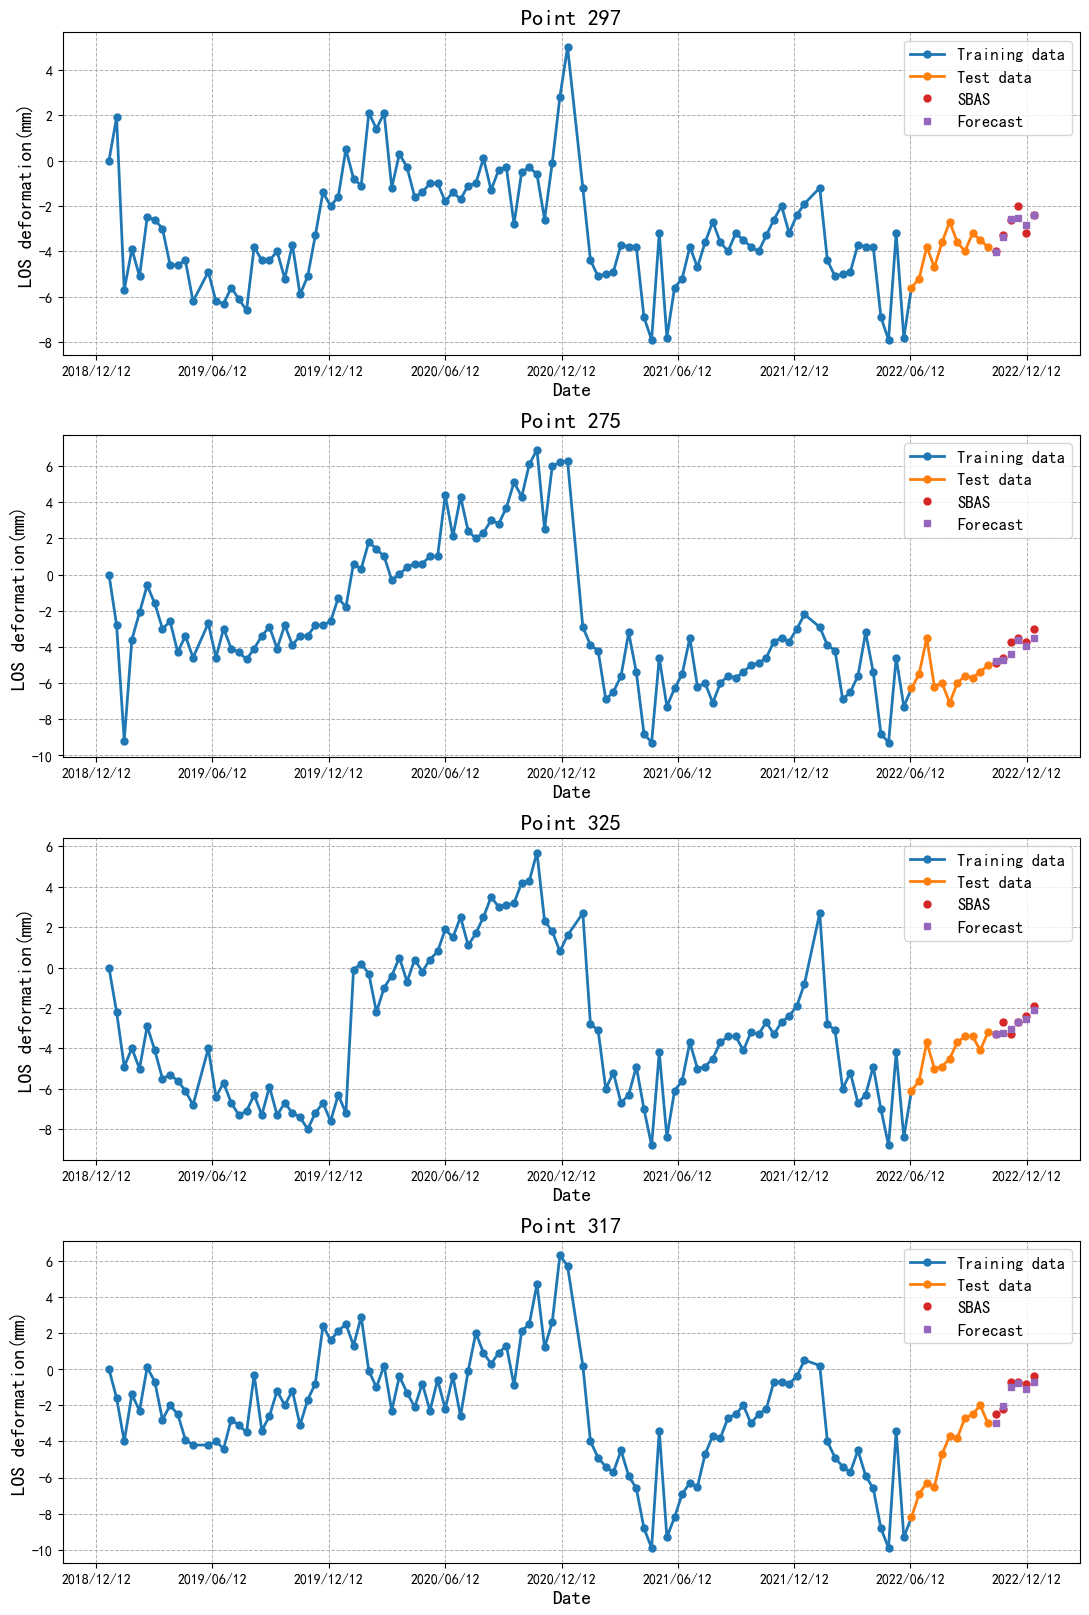

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.signal import savgol_filter
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

rcParams['font.family'] = 'SimHei'  # 设置字体为系统中的SimHei
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 读取CSV文件
filename = r'E:\sar\csv\transposed_output2019all.csv'
data = pd.read_csv(filename)

filename1 = r'E:\repository\prediction_results.csv'
data1 = pd.read_csv(filename1)

# 设置列名列表
column_names =['297', '275', '325', '317']
column_date = 'date'
data[column_date] = pd.to_datetime(data[column_date])
# 创建图形
plt.figure(figsize=(11, 40))  # 调整图形大小

# 循环处理每个列名
for i, column_name in enumerate(column_names, start=1):
    # 获取原始数据
    raw_data = data[column_name]
    column_name2 = f'{column_name}_Pred'
    column_name3 = f'{column_name}_Pred'
    
    raw_data2 = data1[column_name2]
    raw_data3 = data1[column_name3]
    
    # 获取 raw_data 的前 114 个数据
    raw_data_part = raw_data.iloc[:102]
    raw_data_part1 = raw_data.iloc[102:113]
    raw_data_part2 = raw_data.iloc[-6:]
    
    # 获取 raw_data3 的后 6 个数据
    raw_data3_last6 = raw_data3.iloc[-6:]
    
    # 合并 raw_data_part 和 raw_data3_last6
    combined_data = pd.concat([raw_data_part, raw_data3_last6], ignore_index=True)
    
    # 使用Savitzky-Golay滤波器进行平滑，窗口大小为5，阶数为3（可以根据需要调整）
    smoothed_data = savgol_filter(raw_data, window_length=5, polyorder=3)
    
    # 对原始数据进行季节性分解
    decomposition = seasonal_decompose(raw_data, model='additive', period=24)  # 请根据你的数据调整周期

    # 获取季节性分量、趋势分量和残差分量
    seasonal_component = decomposition.seasonal
    trend_component = decomposition.trend
    residual_component = decomposition.resid
    
    # 绘制折线图
    plt.subplot(10, 1, i)  # 每次循环绘制一个子图
    plt.plot(data[column_date][:102], raw_data_part, marker='o', color='tab:blue', linestyle='-', linewidth=2, markersize=5, label='Training data')
    plt.plot([data[column_date].iloc[101], data[column_date].iloc[102]], 
         [raw_data_part.iloc[-1], raw_data_part1.iloc[0]], 
         color='tab:blue', linestyle='-', linewidth=2)
    plt.plot(data[column_date][102:113], raw_data_part1, marker='o', color='tab:orange', linestyle='-', linewidth=2, markersize=5, label='Test data')
   
    plt.plot(data[column_date][-6:], raw_data_part2, marker='o', color='tab:red', linestyle='none', linewidth=2, markersize=5, label='SBAS') 
    plt.plot(data[column_date].iloc[113:119], raw_data3_last6, marker='s', color='tab:purple', linestyle='none', linewidth=2, markersize=5, label='Forecast')
    
    # 设置标题和标签
    plt.title(f'Point {column_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('LOS deformation(mm)', fontsize=14)
    plt.grid(True, which='both', linestyle='--', linewidth=0.7)
    plt.legend(fontsize=12)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
    # plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # 根据数据调整刻度
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=12, interval=6))

# 调整图像布局，避免重叠
plt.tight_layout()
plt.show()
